# Module 01 · Introduction: why transform methods

**Book source:** Bracewell, chapter 1, pp. 1–4

Companion notebook of the lecture with the same module number. Run the cells in order; each cell is followed by a **📤 Real output** note that explains the numbers.

In [1]:
import numpy as np
import matplotlib.pyplot as plt

plt.rcParams.update({"figure.figsize": (7.5, 3.3), "axes.grid": True, "grid.alpha": 0.3, "figure.dpi": 110})


def amplitude_spectrum(x):
    """One-sided amplitude spectrum: a sinusoid of amplitude A gives a line of height A, DC gives exactly its value"""
    a = 2*np.abs(np.fft.rfft(x))/len(x)
    a[0] /= 2
    return a


def report(key, value, fmt=".6g"):
    """Print a named result (the website reads the lines that start with ▸)."""
    print(f"▸ {key} = {value:{fmt}}")


## 1. Waveform and spectrum
🎯 **What question does this method answer?** In a signal made of several mixed sinusoids, how much amplitude does each frequency contribute, and when does reading the spectrum go wrong? We compute it two independent ways: the FFT and the direct sum $X_k=\sum_n x_n e^{-i2\pi kn/N}$ (Bracewell's "slow Fourier transform").

In [2]:
fs, N = 1000, 1000                       # sampling rate (Hz) and number of samples: exactly 1 second, so 1 frequency bin = 1 Hz
t = np.arange(N) / fs
x = 1.0*np.sin(2*np.pi*50*t) + 0.5*np.cos(2*np.pi*120*t) + 0.25*np.sin(2*np.pi*300*t)

# Method A: FFT
amp_fft = amplitude_spectrum(x)

# Method B: direct sum from the definition (no FFT)
n = np.arange(N)
amp_direct = np.array([2*abs(np.sum(x*np.exp(-2j*np.pi*k*n/N)))/N for k in range(N//2 + 1)])
amp_direct[0] /= 2

diff = np.max(np.abs(amp_fft - amp_direct))
assert diff < 1e-9
report("fft_direct_diff", diff, ".1e")
for f in (50, 120, 300):
    report(f"a{f}", amp_fft[f], ".6f")

others = np.ones(len(amp_fft), bool); others[[50, 120, 300]] = False
assert amp_fft[others].max() < 1e-9      # every other bin is zero

▸ fft_direct_diff = 2.4e-14
▸ a50 = 1.000000
▸ a120 = 0.500000
▸ a300 = 0.250000


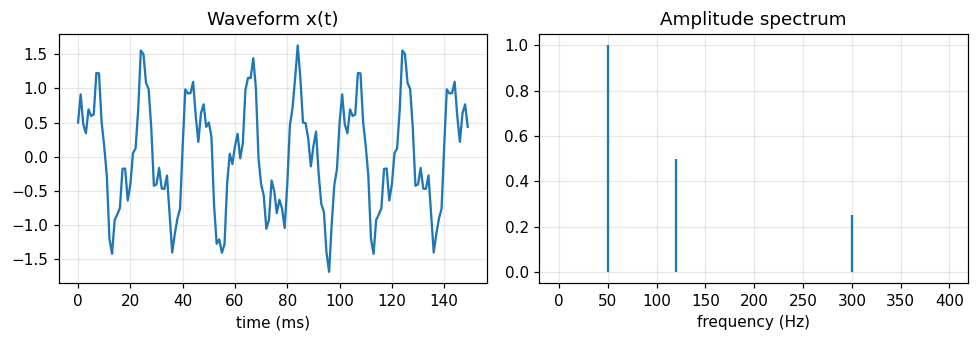

In [3]:
fig, ax = plt.subplots(1, 2, figsize=(9, 3.2))
ax[0].plot(t[:150]*1000, x[:150])
ax[0].set_xlabel("time (ms)"); ax[0].set_title("Waveform x(t)")
ax[1].vlines(np.arange(400), 0, amp_fft[:400])
ax[1].set_xlabel("frequency (Hz)"); ax[1].set_title("Amplitude spectrum")
plt.tight_layout(); plt.show()

#### 📤 Real output
The three recovered amplitudes are 1.000000 (50 Hz), 0.500000 (120 Hz) and 0.250000 (300 Hz), exactly the coefficients built into the signal. The two independent methods differ by at most 2.4e-14, i.e. only by rounding error, and every other bin is zero. That is what "a waveform and its spectrum carry the same information" means: from 1000 messy samples we extract just 6 numbers (3 amplitudes, 3 frequencies).

In [4]:
# Leakage: 50.5 Hz falls on no bin (it sits between bins 50 and 51)
xl = np.sin(2*np.pi*50.5*t)
al = amplitude_spectrum(xl)
pred = abs(np.sinc(0.5))                 # prediction A|sinc(δ)| with δ = 0.5 bin
assert abs(al[50] - pred) < 0.01 and abs(al[51] - pred) < 0.01
report("leak_peak", al[50], ".4f"); report("leak_theory", pred, ".4f"); report("leak_far", al[80], ".4f")

# Phase of sin and cos
ph_sin = np.degrees(np.angle(np.fft.rfft(np.sin(2*np.pi*50*t))[50]))
ph_cos = np.degrees(np.angle(np.fft.rfft(np.cos(2*np.pi*120*t))[120]))
assert abs(ph_sin + 90) < 1e-6 and abs(ph_cos) < 1e-6
report("ph_sin", round(ph_sin, 1) + 0.0, ".1f"); report("ph_cos", round(ph_cos, 1) + 0.0, ".1f")

# Linearity of the transform
x1, x2 = np.sin(2*np.pi*50*t), np.cos(2*np.pi*120*t)
lin_err = np.max(np.abs(np.fft.rfft(x1 + x2) - (np.fft.rfft(x1) + np.fft.rfft(x2))))
assert lin_err < 1e-9
report("lin_err", lin_err, ".1e")

▸ leak_peak = 0.6397
▸ leak_theory = 0.6366
▸ leak_far = 0.0085
▸ ph_sin = -90.0
▸ ph_cos = 0.0
▸ lin_err = 6.2e-14


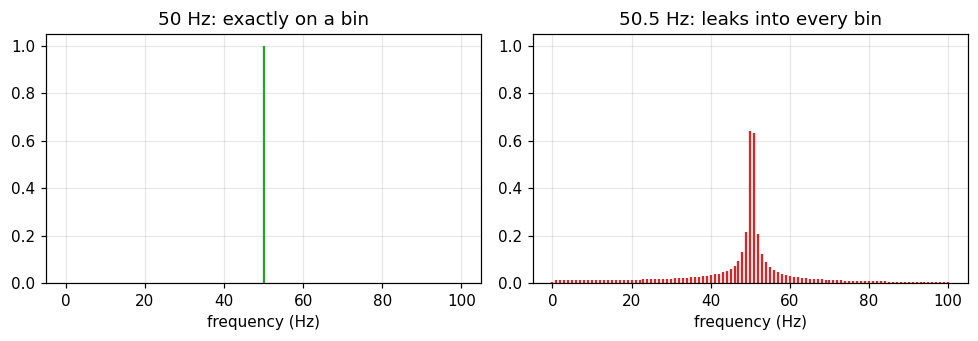

In [5]:
fig, ax = plt.subplots(1, 2, figsize=(9, 3.2))
ax[0].vlines(np.arange(0, 101), 0, amplitude_spectrum(np.sin(2*np.pi*50*t))[:101], colors="tab:green")
ax[0].set_title("50 Hz: exactly on a bin")
ax[1].vlines(np.arange(0, 101), 0, al[:101], colors="tab:red")
ax[1].set_title("50.5 Hz: leaks into every bin")
for a_ in ax: a_.set_xlabel("frequency (Hz)"); a_.set_ylim(0, 1.05)
plt.tight_layout(); plt.show()

#### 📤 Real output
The 50.5 Hz wave gives bin-50 amplitude 0.6397 instead of 1; the prediction $|\text{sinc}(0.5)|$ is 0.6366, matching within 0.01. Even bin 80, 30 bins from the peak, still holds 0.0085: this is leakage, the consequence of cutting the signal with a rectangular window. The phase of $\sin$ at bin 50 is -90.0 degrees and of $\cos$ at bin 120 is 0.0 degrees. Linearity of the transform is confirmed: deviation 6.2e-14.

## 2. Energy and convolution: two classic numerical checks
🎯 **What question does this method answer?** Does changing domain lose or add information, and is convolution in the original domain really multiplication in the frequency domain? We check with energy conservation and with Bracewell's serial-product example (p. 32).

In [6]:
# A deterministic (non-random) signal so results are reproducible
n = np.arange(1000)
xr = np.cos(2*np.pi*7*n/1000)*np.exp(-n/300) + 0.3*np.sin(2*np.pi*41*n/1000)
e_time = np.sum(xr**2)
e_freq = np.sum(np.abs(np.fft.fft(xr))**2)/len(xr)
assert np.isclose(e_time, e_freq)
report("energy_time", e_time, ".6f"); report("energy_freq", e_freq, ".6f")

# Bracewell's serial product (p. 32)
f = np.array([2, 2, 3, 3, 4]); g = np.array([1, 1, 2])
c_direct = np.convolve(f, g)                                   # method A: direct sum
L = len(f) + len(g) - 1
c_fft = np.fft.irfft(np.fft.rfft(f, L)*np.fft.rfft(g, L), L)   # method B: multiply two FFTs then invert
assert np.allclose(c_direct, c_fft)
assert c_direct.sum() == f.sum()*g.sum()
report("conv_direct", " ".join(str(v) for v in c_direct), "s")
report("sum_f", int(f.sum()), "d"); report("sum_g", int(g.sum()), "d"); report("conv_sum", int(c_direct.sum()), "d")

▸ energy_time = 123.132814
▸ energy_freq = 123.132814
▸ conv_direct = 2 4 9 10 13 10 8
▸ sum_f = 14
▸ sum_g = 4
▸ conv_sum = 56


#### 📤 Real output
The time-domain energy 123.132814 equals the frequency-domain energy 123.132814: changing domain loses no information. The serial product gives the sequence 2 4 9 10 13 10 8 by both methods, as Bracewell computes by hand, and the sum of terms 56 equals the product of the sums 14 times 4.

## 3. A linear invariant system keeps the frequency
🎯 **What question does this method answer?** What does the low-pass filter $y[n]=a\,y[n-1]+(1-a)x[n]$ do to a sinusoid? We measure gain and phase with an FFT, compare with the frequency response $H(\omega)=\dfrac{1-a}{1-a\,e^{-i\omega}}$, and compare the impulse response $h[n]=(1-a)a^n$ with the <code>lfilter</code> function.

In [7]:
from scipy.signal import lfilter

a = 0.9                                  # filter coefficient

def lowpass_loop(x, a):                  # hand-written loop, independent of SciPy
    y, prev = np.zeros_like(x), 0.0
    for i, xi in enumerate(x):
        prev = a*prev + (1 - a)*xi
        y[i] = prev
    return y

x0 = np.sin(2*np.pi*50*np.arange(2000)/fs + 0.3)   # 50 Hz wave, initial phase 0.3 rad, 2 s long
y_scipy = lfilter([1 - a], [1, -a], x0)
y_loop = lowpass_loop(x0, a)
assert np.allclose(y_scipy, y_loop)

# Impulse response h[n] and direct convolution
h = (1 - a)*a**np.arange(300)
y_conv = np.convolve(x0, h)[:len(x0)]
conv_diff = np.max(np.abs(y_conv - y_scipy))
assert conv_diff < 1e-9
report("conv_lfilter_diff", conv_diff, ".1e"); report("h_sum", h.sum(), ".6f")

xs, ys = x0[1000:], y_scipy[1000:]       # drop the first second (transient), analyse the steady second
Xs, Ys = np.fft.rfft(xs), np.fft.rfft(ys)
f_out = int(np.argmax(np.abs(Ys)))
gain_meas = abs(Ys[50]) / abs(Xs[50])
phase_meas = np.angle(np.exp(1j*(np.angle(Ys[50]) - np.angle(Xs[50]))))

w = 2*np.pi*50/fs
H = (1 - a)/(1 - a*np.exp(-1j*w))        # theoretical frequency response
assert abs(gain_meas - abs(H)) < 1e-6 and abs(phase_meas - np.angle(H)) < 1e-6

report("f_out", f_out, "d")
report("gain_meas", gain_meas, ".6f");   report("gain_theory", abs(H), ".6f")
report("phase_meas_deg", np.degrees(phase_meas), ".3f");  report("phase_theory_deg", np.degrees(np.angle(H)), ".3f")

# Measure the gain at several frequencies
meas = {50: gain_meas}
for fq in (25, 100, 200):
    xin = np.sin(2*np.pi*fq*np.arange(2000)/fs)
    yout = lfilter([1 - a], [1, -a], xin)[1000:]
    G = abs(np.fft.rfft(yout)[fq]) / abs(np.fft.rfft(xin[1000:])[fq])
    Ht = abs((1 - a)/(1 - a*np.exp(-1j*2*np.pi*fq/fs)))
    assert abs(G - Ht) < 1e-6
    meas[fq] = G
    report(f"gain_{fq}", G, ".6f")

▸ conv_lfilter_diff = 8.2e-15
▸ h_sum = 1.000000
▸ f_out = 50
▸ gain_meas = 0.319278
▸ gain_theory = 0.319278
▸ phase_meas_deg = -62.618
▸ phase_theory_deg = -62.618
▸ gain_25 = 0.557616
▸ gain_100 = 0.168128
▸ gain_200 = 0.089308


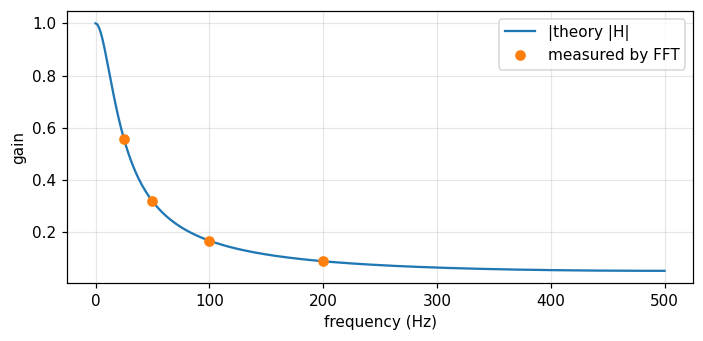

In [8]:
ff = np.linspace(0, 500, 501)
Hc = np.abs((1 - a)/(1 - a*np.exp(-1j*2*np.pi*ff/fs)))
plt.figure(figsize=(6.5, 3.2))
plt.plot(ff, Hc, label="|theory |H|")
plt.plot(list(meas), list(meas.values()), "o", label="measured by FFT")
plt.xlabel("frequency (Hz)"); plt.ylabel("gain"); plt.legend()
plt.tight_layout(); plt.show()

#### 📤 Real output
The output still peaks at 50 Hz: the frequency is unchanged. The filter only changes the amplitude (measured gain 0.319278, theory 0.319278) and the phase (measured -62.618 degrees, theory -62.618 degrees; negative means the output lags). The hand-written loop, <code>lfilter</code> and convolution with $h[n]$ give the same answer (difference 8.2e-15), and the sum of $h$ is 1.000000 so the DC gain is 1. The gain falls with frequency: 0.557616 at 25 Hz, 0.168128 at 100 Hz, 0.089308 at 200 Hz.

## 4. When the conditions fail
🎯 **What question does this method answer?** If the system is nonlinear (a squarer, a cubic stage) or time-varying (a cosine multiplier), how does the output spectrum differ from that of a linear invariant system? Unlike part 3, the output frequency no longer equals the input frequency.

In [9]:
xt = np.sin(2*np.pi*50*np.arange(1000)/fs)

# Nonlinear system: a squarer
An = amplitude_spectrum(xt**2)
nl_dc, nl_a100, nl_a50 = An[0], An[100], An[50]

# Linear but time-varying: multiply by cos(2π·20t)
At = amplitude_spectrum(xt*np.cos(2*np.pi*20*np.arange(1000)/fs))
tv_a30, tv_a70, tv_a50 = At[30], At[70], At[50]

assert abs(nl_dc - 0.5) < 1e-9 and abs(nl_a100 - 0.5) < 1e-9 and nl_a50 < 1e-9
assert abs(tv_a30 - 0.5) < 1e-9 and abs(tv_a70 - 0.5) < 1e-9 and tv_a50 < 1e-9
for k, v in dict(nl_dc=nl_dc, nl_a100=nl_a100, nl_a50=nl_a50, tv_a30=tv_a30, tv_a70=tv_a70).items():
    report(k, abs(v), ".6f")

# Cubic stage y = x + 0.1x³ and harmonic distortion
Ac = amplitude_spectrum(xt + 0.1*xt**3)
fund, h3 = Ac[50], Ac[150]
assert abs(fund - 1.075) < 1e-9 and abs(h3 - 0.025) < 1e-9     # sin³θ = (3 sinθ − sin3θ)/4
report("cubic_fund", fund, ".6f"); report("cubic_h3", h3, ".6f"); report("cubic_thd_pct", 100*h3/fund, ".4f")

▸ nl_dc = 0.500000
▸ nl_a100 = 0.500000
▸ nl_a50 = 0.000000
▸ tv_a30 = 0.500000
▸ tv_a70 = 0.500000
▸ cubic_fund = 1.075000
▸ cubic_h3 = 0.025000
▸ cubic_thd_pct = 2.3256


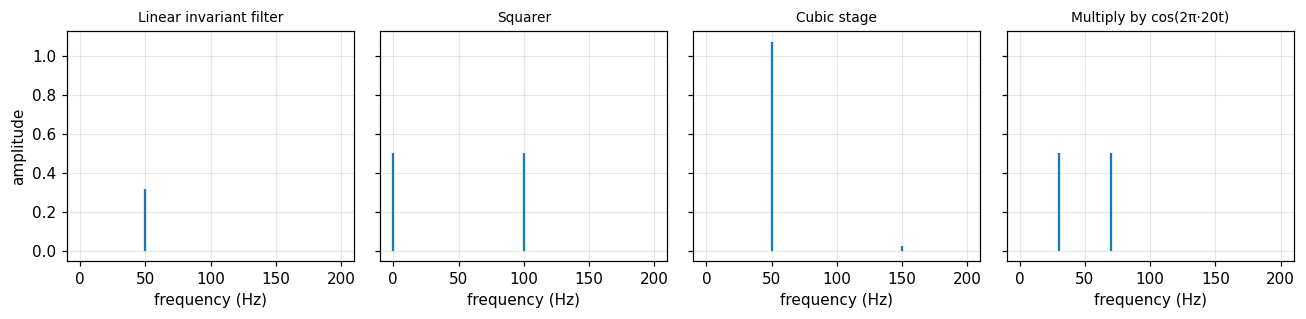

In [10]:
fr = np.arange(0, 201)
fig, ax = plt.subplots(1, 4, figsize=(12, 3), sharey=True)
panels = [(amplitude_spectrum(ys), "Linear invariant filter"),
          (An, "Squarer"),
          (Ac, "Cubic stage"),
          (At, "Multiply by cos(2π·20t)")]
for a_, (s, ttl) in zip(ax, panels):
    a_.vlines(fr, 0, s[:201]); a_.set_title(ttl, fontsize=9); a_.set_xlabel("frequency (Hz)")
ax[0].set_ylabel("amplitude")
plt.tight_layout(); plt.show()

#### 📤 Real output
The squarer gives DC 0.500000 and 100 Hz with amplitude 0.500000, with only 0.000000 left at 50 Hz. The cosine multiplier gives 30 Hz and 70 Hz with equal amplitudes 0.500000 and 0.500000 (from $\cos A\cos B=\tfrac12[\cos(A-B)+\cos(A+B)]$). The cubic stage gives a fundamental 1.075000 and a third harmonic 0.025000, i.e. a THD of 2.3256%, exactly as $\sin^3\theta=\tfrac34\sin\theta-\tfrac14\sin3\theta$ predicts. Conclusion: a spectral line at a foreign frequency is the signature of nonlinearity or time variation. That is why the theory in the book rests on linear invariant systems, where the response is a convolution.

## 5. Notation: gate, convolution and impulse
🎯 **What question does this method answer?** Do the symbols $\Pi$, $*$ and $\delta$ behave as the book describes? We check with numerical integrals against closed forms, and with a sequence of narrowing rectangular pulses $\delta_\varepsilon$.

In [11]:
from scipy import integrate, special

# Gate: ∫ Π(x) cos(πx) dx = integral from −1/2 to 1/2 of cos(πx) = 2/π
gate_area, _ = integrate.quad(lambda u: np.cos(np.pi*u), -0.5, 0.5)
assert abs(gate_area - 2/np.pi) < 1e-12
report("gate_area", gate_area, ".6f")

# Running mean Π*f at x = 0 with f(u) = exp(−u²): numerical integral versus √π·erf(1/2)
run_num, _ = integrate.quad(lambda u: np.exp(-u**2), -0.5, 0.5)
run_exact = np.sqrt(np.pi)*special.erf(0.5)
assert abs(run_num - run_exact) < 1e-12
report("run_mean_num", run_num, ".6f"); report("run_mean_exact", run_exact, ".6f")

# Sifting property: ∫ cos(x) δ_ε(x) dx → cos(0) = 1
for tag, eps in (("e05", 0.5), ("e01", 0.1), ("e001", 0.01)):
    val, _ = integrate.quad(lambda u: np.cos(u)/eps, -eps/2, eps/2)
    exact = 2*np.sin(eps/2)/eps
    assert abs(val - exact) < 1e-12
    report(f"sift_{tag}", val, ".6f")

▸ gate_area = 0.636620
▸ run_mean_num = 0.922562
▸ run_mean_exact = 0.922562
▸ sift_e05 = 0.989616
▸ sift_e01 = 0.999583
▸ sift_e001 = 0.999996


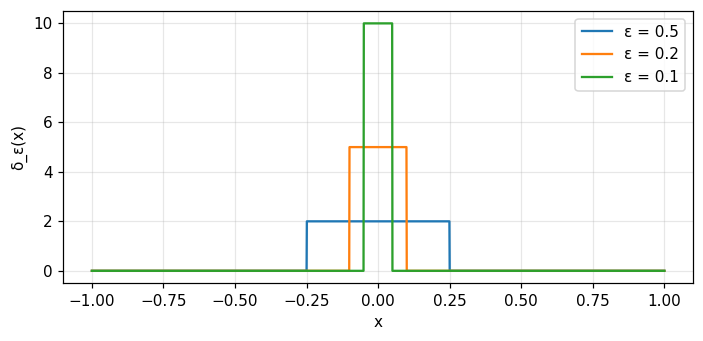

In [12]:
xx = np.linspace(-1, 1, 2001)
plt.figure(figsize=(6.5, 3.2))
for eps, c in ((0.5, "tab:blue"), (0.2, "tab:orange"), (0.1, "tab:green")):
    plt.plot(xx, np.where(np.abs(xx) < eps/2, 1/eps, 0.0), color=c, label=f"ε = {eps}")
plt.xlabel("x"); plt.ylabel("δ_ε(x)"); plt.legend()
plt.tight_layout(); plt.show()

#### 📤 Real output
The integral $\int\Pi(x)\cos(\pi x)\,dx$ equals 0.636620, exactly $2/\pi$. The running mean of $e^{-u^2}$ at the origin is 0.922562 by numerical integration and 0.922562 by the closed form. The sifting table gives 0.989616 for ε=0.5, 0.999583 for ε=0.1, 0.999996 for ε=0.01, approaching $\cos 0=1$. So an expression containing $\delta$ has meaning exactly as Bracewell describes: as the limit of a sequence of pulses of finite width, not as a function at a point.